In [36]:
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# PyTorch Imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.model_selection import train_test_split 

#Shap for Explainability
import lime # ADDED: For model explainability
from lime.lime_tabular import LimeTabularExplainer # Import LIME Tabular Explainer


### Config variables

In [27]:
### Set-up - Define file location
filenames = ['N-CMAPSS_DS01.h5', 'N-CMAPSS_DS02.h5', 'N-CMAPSS_DS03.h5', 'N-CMAPSS_DS04.h5', 'N-CMAPSS_DS05.h5', 'N-CMAPSS_DS06.h5', 'N-CMAPSS_DS07.h5']

COLUMN_RENAME_MAP = {
    'TRA': 'Throttle Resolver Angle',
    'T2': 'Total Temperature at Fan Inlet', 
    'T24': 'LPC Outlet Temperature',
    'T30': 'HPC Inlet Temperature',
    'T50': 'LPT Outlet Temperature',
    'P2': 'Fan Inlet Pressure',
    'P15': 'Pressure in Bypass Duct',
    'P30': 'HPC Outlet Pressure',
    'Ps30': 'HPC Outlet Static Pressure',
    'Nf': 'Fan Speed',
    'Nc': 'Core Speed',
    'T48': 'HPT Outlet Temperature',
    'P45': 'Total Pressure at HPT Outlet',
    'T40': 'Total Temperature at Burner Outlet',
    'Wf': 'Fuel Flow',
    'phi': 'Fuel Flow Ratio',
    'W21': 'Fan Flow',
    'W22': 'LPC Flow',
    'W25': 'HPC Flow',
    'W31': 'HPT Coolant Bleed',
    'W32': 'LPT Coolant Bleed',
    'SmFan': 'Fan Stall Margin',
    'SmLPC': 'LPC Stall Margin',
    'SmHPC': 'HPC Stall Margin',
    'Fc': 'Flight Class',
    'hs': 'Health Status'
}

# Datasets 2 and 7 are held out for the final OOT test due to their unique operational profiles.
TRAIN_SETS = [1, 3, 4, 5, 6] #don't be confuesd it's actually train+val+test but it does not mix it's just named train
OOT_SETS = [2, 7] 

EMA_SPAN = 10
HEALTHY_WINDOW = 20
SEQUENCE_LENGTH = 30
BATCH_SIZE = 256
LEARNING_RATE = 0.001
EPOCHS = 50

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_SAVE_PATH = 'rul_lstm_model.pt'

### Data Loading and Preprocessing

The goal is to build a pure data-driven "black box" model that could infer the engine's health (RUL) solely from the observed sensor data (X_s and X_v) and operational settings (W). The actual degradation mechanism (the T array) is hidden, making the task more realistic for industrial data scientists who often don't have access to the underlying physical model.

In [3]:
def load_data(filenames):
    # Data containers
    all_W = []
    all_X_s = []
    all_X_v = []
    #all_T = [] # T (Degradation Parameters) removed for 'black box' philosophy
    all_Y = []
    all_A = []
    
    for idx, filename in enumerate(filenames):
        dataset_num = idx + 1  # 1 to 7
        print(f"\nLoading {filename} (Dataset {dataset_num})...\n")
        with h5py.File(filename, 'r') as hdf:
            # Load all arrays
            W_dev = np.array(hdf.get('W_dev'))             
            X_s_dev = np.array(hdf.get('X_s_dev'))         
            X_v_dev = np.array(hdf.get('X_v_dev'))         
            T_dev = np.array(hdf.get('T_dev'))             
            Y_dev = np.array(hdf.get('Y_dev'))             
            A_dev = np.array(hdf.get('A_dev'))             

            W_test = np.array(hdf.get('W_test'))           
            X_s_test = np.array(hdf.get('X_s_test'))       
            X_v_test = np.array(hdf.get('X_v_test'))       
            T_test = np.array(hdf.get('T_test'))           
            Y_test = np.array(hdf.get('Y_test'))           
            A_test = np.array(hdf.get('A_test'))           
            
            # Varnams (Simplified decoding)
            W_var = [str(x) for x in hdf.get('W_var')[:]]
            X_s_var = [str(x) for x in hdf.get('X_s_var')[:]]  
            X_v_var = [str(x) for x in hdf.get('X_v_var')[:]] 
            T_var = [str(x) for x in hdf.get('T_var')[:]]
            A_var = [str(x) for x in hdf.get('A_var')[:]]
            
            print("W_var (Scenario Descriptors):", W_var)
            print("X_s_var (Measurements/Sensors):", X_s_var)
            print("X_v_var (Virtual Sensors):", X_v_var)
            print("T_var (Degradation Parameters):", T_var)
            print("A_var (Auxiliary Data):", A_var)
            
        # Concatenate dev and test for this file
        W = np.concatenate((W_dev, W_test), axis=0)  
        X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
        X_v = np.concatenate((X_v_dev, X_v_test), axis=0)
        # T = np.concatenate((T_dev, T_test), axis=0) # Excluded
        Y = np.concatenate((Y_dev, Y_test), axis=0) 
        A = np.concatenate((A_dev, A_test), axis=0) 
        
        # A_new will capture the full set of auxiliary data plus the dataset ID
        # A_new columns: [dataset_id, unit, cycle, Fc, hs]
        A_new = np.zeros((A.shape[0], A.shape[1] + 1), dtype=object) 
        A_new[:, 0] = dataset_num # Column 0: dataset ID (1, 2, 3...)
        A_new[:, 1:] = A          # Columns 1-4: unit, cycle, Fc, hs
        
        all_W.append(W)
        all_X_s.append(X_s)
        all_X_v.append(X_v)
        # all_T.append(T) # Excluded
        all_Y.append(Y)
        all_A.append(A_new) 
    
    # Concatenate across all files
    W = np.concatenate(all_W, axis=0)
    X_s = np.concatenate(all_X_s, axis=0)
    X_v = np.concatenate(all_X_v, axis=0)
    # T = np.concatenate(all_T, axis=0) # Excluded
    Y = np.concatenate(all_Y, axis=0)
    A = np.concatenate(all_A, axis=0)
    
    print(f"\nFinal concatenated shapes - W: {W.shape}, X_s: {X_s.shape}, X_v: {X_v.shape}, Y: {Y.shape}, A: {A.shape}")
    
    # Return T as None
    return W, X_s, X_v, None, Y, A 
        
        
def create_df(A_data, W_data, X_s_data, X_v_data, T_data, Y_data=None):
    df = pd.DataFrame()
        
    df['dataset'] = A_data[:, 0].astype(int)
    df['unit_orig'] = A_data[:, 1].astype(int)
    df['time'] = A_data[:, 2].astype(int) 
    df['Fc'] = A_data[:, 3].astype(int)
    df['hs'] = A_data[:, 4].astype(int)

    df['unit'] = df.apply(lambda row: f"DS{int(row['dataset']):02d}_{int(row['unit_orig']):03d}", axis=1)
    
    # --- Operational Settings Columns (W_var) ---
    df['Altitude'] = W_data[:, 0]
    df['Mach_Number'] = W_data[:, 1]
    df['TRA'] = W_data[:, 2]
    df['T2'] = W_data[:, 3]
    
    # --- Sensor Measurement Columns (X_s_var) ---
    df['T24'] = X_s_data[:, 0]
    df['T30'] = X_s_data[:, 1]
    df['T48'] = X_s_data[:, 2] 
    df['T50'] = X_s_data[:, 3]
    df['P15'] = X_s_data[:, 4]
    df['P2'] = X_s_data[:, 5]
    df['P21'] = X_s_data[:, 6]
    df['P24'] = X_s_data[:, 7]
    df['Ps30'] = X_s_data[:, 8]
    df['P40'] = X_s_data[:, 9]
    df['P50'] = X_s_data[:, 10]
    df['Nf'] = X_s_data[:, 11]
    df['Nc'] = X_s_data[:, 12]
    df['Wf'] = X_s_data[:, 13]
    
    # --- Virtual Sensor Columns (X_v_var) ---
    df['T40'] = X_v_data[:, 0]
    df['P30'] = X_v_data[:, 1]
    df['P45'] = X_v_data[:, 2]
    df['W21'] = X_v_data[:, 3]
    df['W22'] = X_v_data[:, 4]
    df['W25'] = X_v_data[:, 5]
    df['W31'] = X_v_data[:, 6]
    df['W32'] = X_v_data[:, 7]
    df['W48'] = X_v_data[:, 8]
    df['W50'] = X_v_data[:, 9]
    df['SmFan'] = X_v_data[:, 10]
    df['SmLPC'] = X_v_data[:, 11]
    df['SmHPC'] = X_v_data[:, 12]
    df['phi'] = X_v_data[:, 13]
    
    # --- Column Renaming for Readability and Consistency ---
    df = df.rename(columns=COLUMN_RENAME_MAP)
    
    if Y_data is not None:
        df['Remaining Useful Life'] = Y_data
        
    return df

In [4]:
# Load all datasets
print("\n=== 1. Loading Data ===\n")
W, X_s, X_v, T, Y, A = load_data(filenames)

# Create combined dataframe
print("\n=== Creating Combined Dataframe ===\n")
df_combined = create_df(A, W, X_s, X_v, T, Y) 
print(df_combined.head())


=== 1. Loading Data ===


Loading N-CMAPSS_DS01.h5 (Dataset 1)...

W_var (Scenario Descriptors): ["b'alt'", "b'Mach'", "b'TRA'", "b'T2'"]
X_s_var (Measurements/Sensors): ["b'T24'", "b'T30'", "b'T48'", "b'T50'", "b'P15'", "b'P2'", "b'P21'", "b'P24'", "b'Ps30'", "b'P40'", "b'P50'", "b'Nf'", "b'Nc'", "b'Wf'"]
X_v_var (Virtual Sensors): ["b'T40'", "b'P30'", "b'P45'", "b'W21'", "b'W22'", "b'W25'", "b'W31'", "b'W32'", "b'W48'", "b'W50'", "b'SmFan'", "b'SmLPC'", "b'SmHPC'", "b'phi'"]
T_var (Degradation Parameters): ["b'fan_eff_mod'", "b'fan_flow_mod'", "b'LPC_eff_mod'", "b'LPC_flow_mod'", "b'HPC_eff_mod'", "b'HPC_flow_mod'", "b'HPT_eff_mod'", "b'HPT_flow_mod'", "b'LPT_eff_mod'", "b'LPT_flow_mod'"]
A_var (Auxiliary Data): ["b'unit'", "b'cycle'", "b'Fc'", "b'hs'"]

Loading N-CMAPSS_DS02.h5 (Dataset 2)...

W_var (Scenario Descriptors): ["b'alt'", "b'Mach'", "b'TRA'", "b'T2'"]
X_s_var (Measurements/Sensors): ["b'T24'", "b'T30'", "b'T48'", "b'T50'", "b'P15'", "b'P2'", "b'P21'", "b'P24'", "b'Ps30'

In [5]:
print("\n=== 2. Check Data Loading ===\n")
print("\nInfo:", df_combined.info())

print("Number of Engines (units):", df_combined['unit'].nunique())

#number of engines per dataset
for ds in sorted(df_combined['dataset'].unique()):
    num_units = df_combined[df_combined['dataset'] == ds]['unit'].nunique()
    print(f"Dataset {ds}: {num_units} engines")

# Print the cycle count per engine
print("\nMax OPERATIONAL cycle count per engine (unit):")
for unit, group in df_combined.groupby('unit'):
    max_cycle = group['time'].max()
    print(f"{unit}: {max_cycle} operational cycles")



=== 2. Check Data Loading ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54874178 entries, 0 to 54874177
Data columns (total 39 columns):
 #   Column                              Dtype  
---  ------                              -----  
 0   dataset                             int64  
 1   unit_orig                           int64  
 2   time                                int64  
 3   Flight Class                        int64  
 4   Health Status                       int64  
 5   unit                                object 
 6   Altitude                            float64
 7   Mach_Number                         float64
 8   Throttle Resolver Angle             float64
 9   Total Temperature at Fan Inlet      float64
 10  LPC Outlet Temperature              float64
 11  HPC Inlet Temperature               float64
 12  HPT Outlet Temperature              float64
 13  LPT Outlet Temperature              float64
 14  Pressure in Bypass Duct             float64
 15  Fan Inlet Press

### EDA

In [6]:
# EDA Section

print("\n=== 3. Data Integrity and Redundancy Checks ===\n")

# 1. Missing Values Check (NaN)
print("Missing Values (NaN) Check:")
nan_counts = df_combined.isnull().sum()
nan_cols = nan_counts[nan_counts > 0]

if nan_cols.empty:
    print("No missing (NaN) values found in the combined dataset. Data is clean.")
else:
    print("WARNING: Missing values found in the following columns:")
    print(nan_cols)

print("\nConstant/Non-Trending Feature Check:")

# Collect all sensor and operational features (excluding IDs and RUL)
exclude_cols = ['dataset', 'unit_orig', 'time', 'unit', 'Flight Class', 'Health Status', 'Remaining Useful Life']
feature_cols = [col for col in df_combined.columns if col not in exclude_cols]

# Calculate statistics
feature_stats = df_combined[feature_cols].describe().T
feature_stats['std_ratio'] = feature_stats['std'] / feature_stats['mean'].abs()

# Identify truly constant features (std == 0)
constant_features = feature_stats[feature_stats['std'] == 0].index.tolist()

# Identify features with very low variance (e.g., std is less than 0.1% of the mean)
# This threshold (0.001) might need tuning, but it flags nearly useless features
low_variance_features = feature_stats[(feature_stats['std'] > 0) & (feature_stats['std_ratio'] < 0.001)].index.tolist()

if constant_features:
    print(f"\n* Constant Features (STD=0): These should be removed.\n{constant_features}")
else:
    print("* No strictly constant features found (STD=0).")

if low_variance_features:
    print(f"\n* Low Variance Features (STD < 0.1% of Mean): Consider removing.\n{low_variance_features}")
else:
    print("* No extremely low variance features found.")


=== 3. Data Integrity and Redundancy Checks ===

Missing Values (NaN) Check:
No missing (NaN) values found in the combined dataset. Data is clean.

Constant/Non-Trending Feature Check:
* No strictly constant features found (STD=0).
* No extremely low variance features found.



=== 4. Dataset Description ===

            dataset     unit_orig          time  Flight Class  Health Status  \
count  5.487418e+07  5.487418e+07  5.487418e+07  5.487418e+07   5.487418e+07   
mean   3.933467e+00  6.685558e+00  4.035832e+01  2.403583e+00   2.701724e-01   
std    1.925442e+00  4.194317e+00  2.397520e+01  7.370058e-01   4.440488e-01   
min    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   0.000000e+00   
25%    2.000000e+00  3.000000e+00  2.000000e+01  2.000000e+00   0.000000e+00   
50%    4.000000e+00  6.000000e+00  4.000000e+01  3.000000e+00   0.000000e+00   
75%    6.000000e+00  9.000000e+00  5.900000e+01  3.000000e+00   1.000000e+00   
max    7.000000e+00  2.000000e+01  1.000000e+02  3.000000e+00   1.000000e+00   

           Altitude   Mach_Number  Throttle Resolver Angle  \
count  5.487418e+07  5.487418e+07             5.487418e+07   
mean   1.652401e+04  5.488022e-01             6.160129e+01   
std    8.112256e+03  1.192293e-01             1.808809e+01  

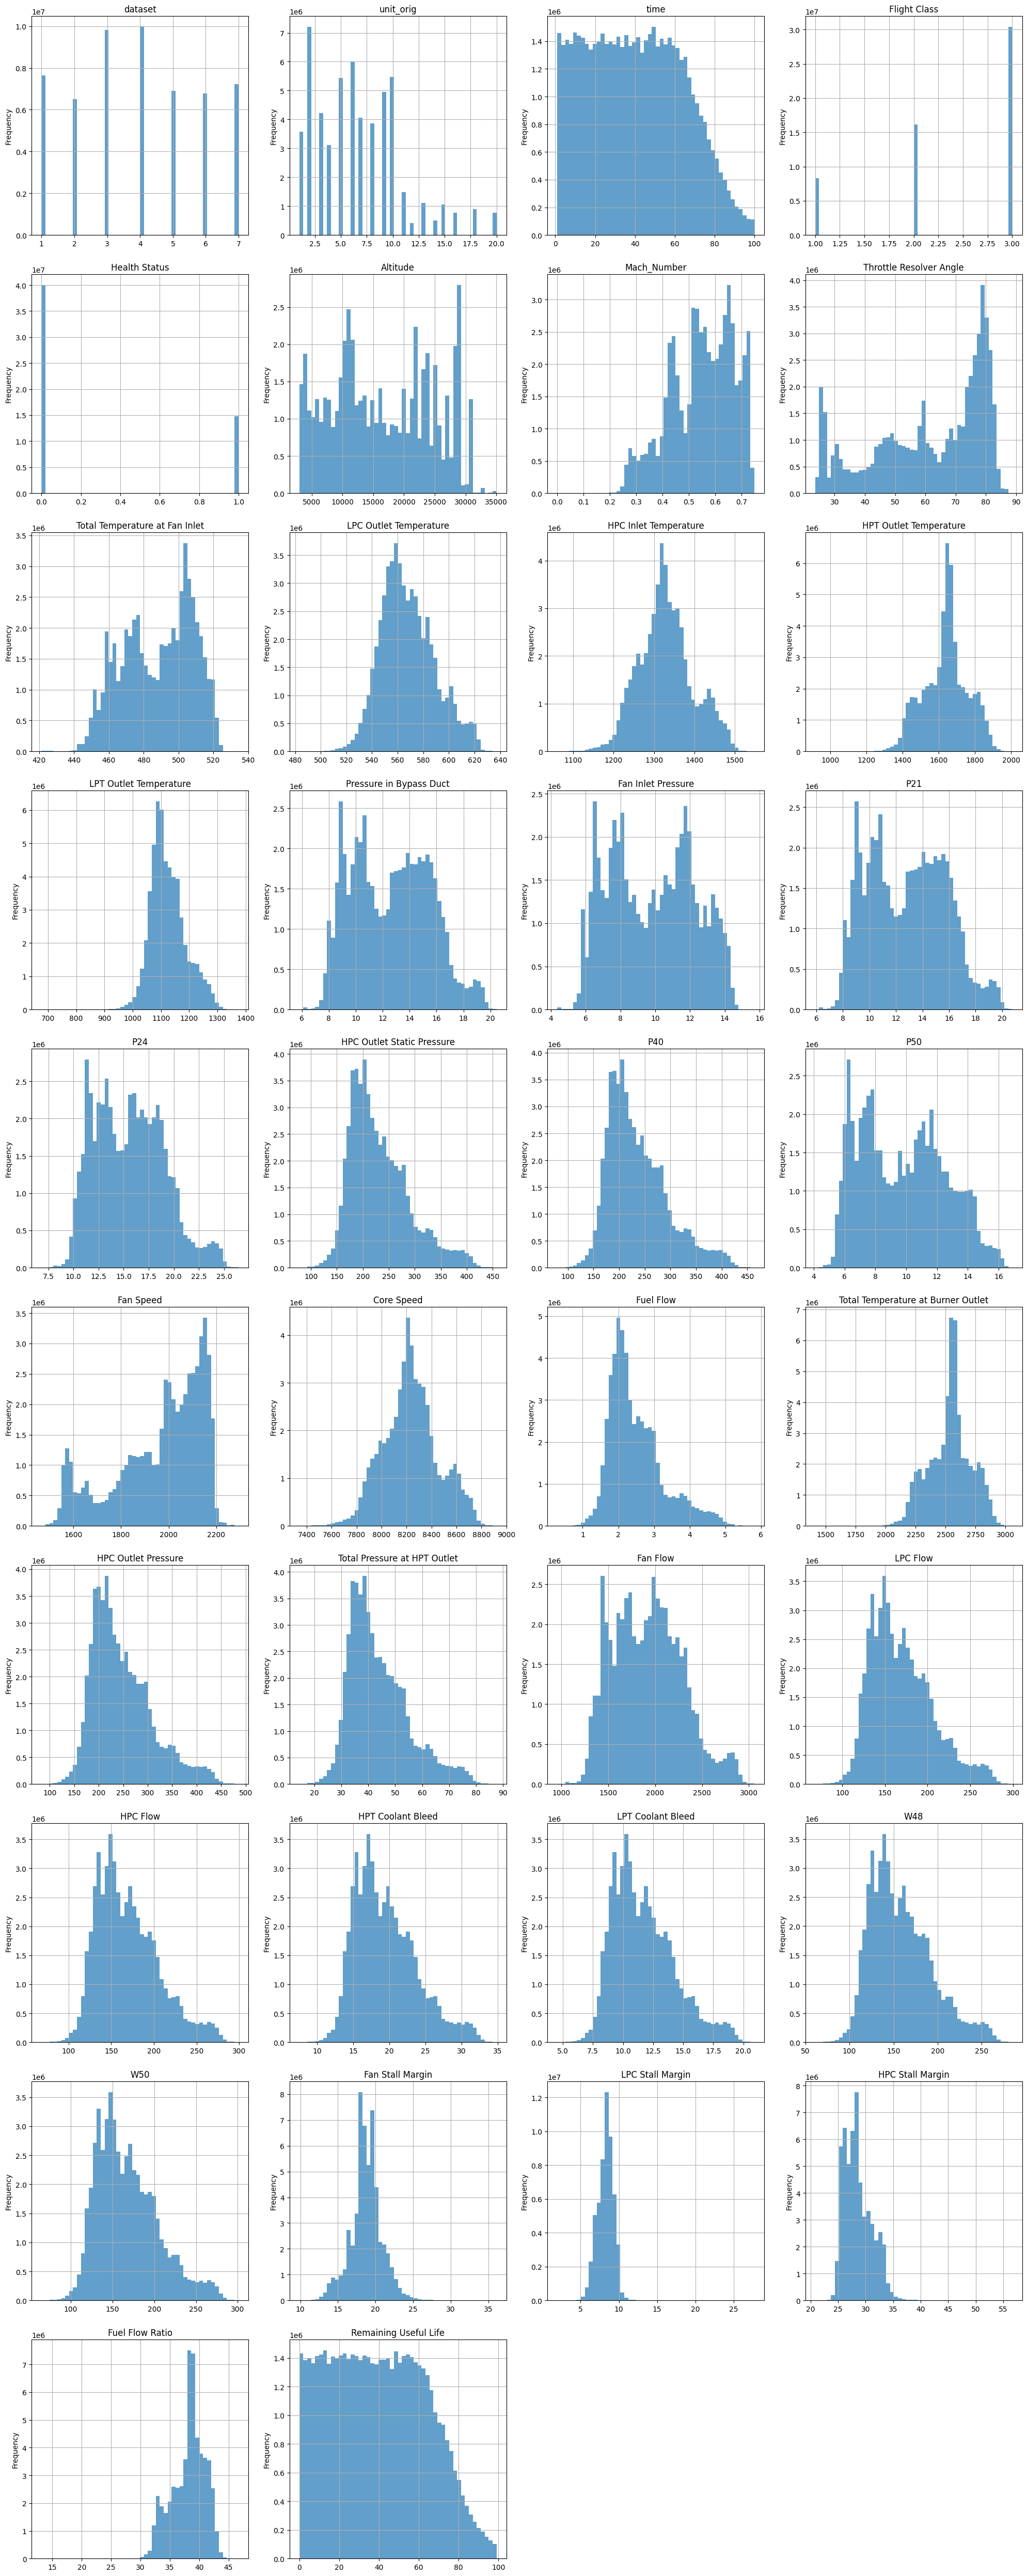

In [7]:
print("\n=== 4. Dataset Description ===\n")
print(df_combined.describe())

# Distribution of all columns (compact view)
print("\n=== Column Distributions ===")
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
n_cols = len(numeric_cols)
n_rows = (n_cols // 4) + 1

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        df_combined[col].hist(bins=50, ax=axes[i], alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


=== 5. Average Sensor Trends vs Time per Dataset (Smoothed) ===


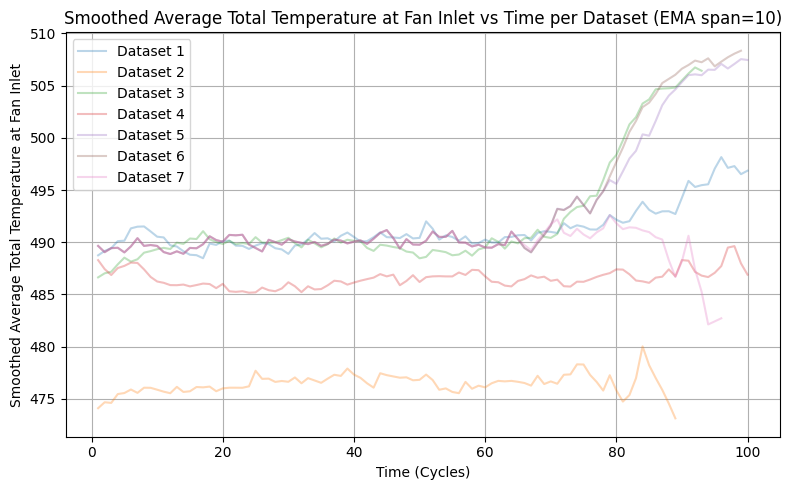

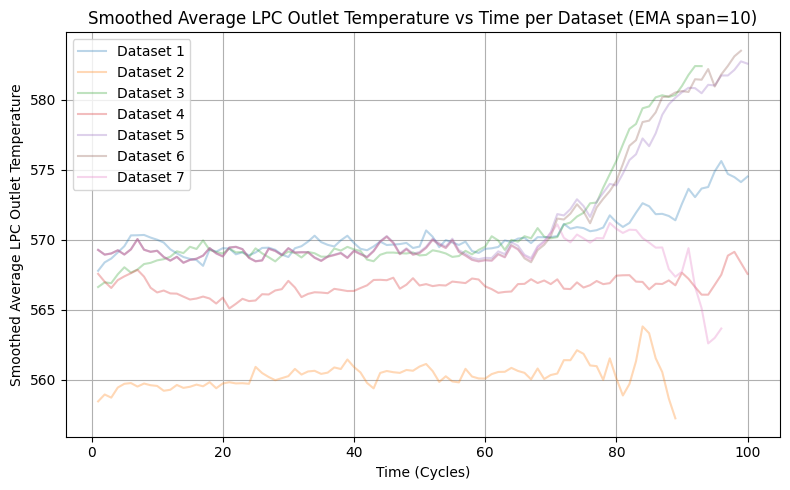

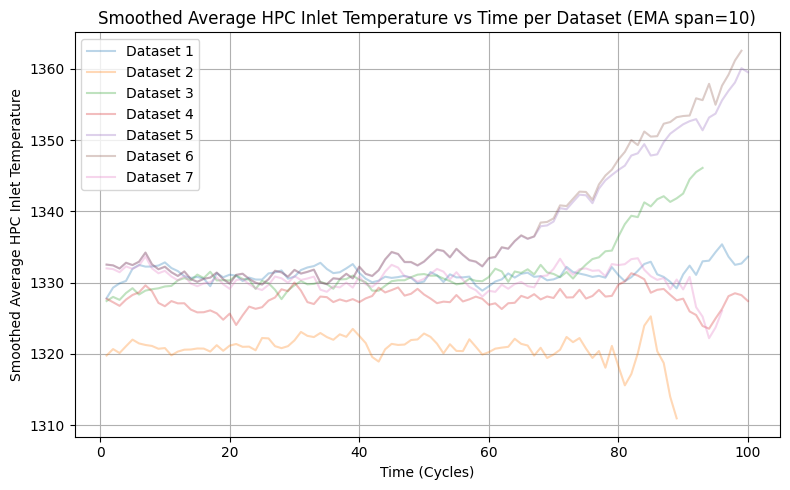

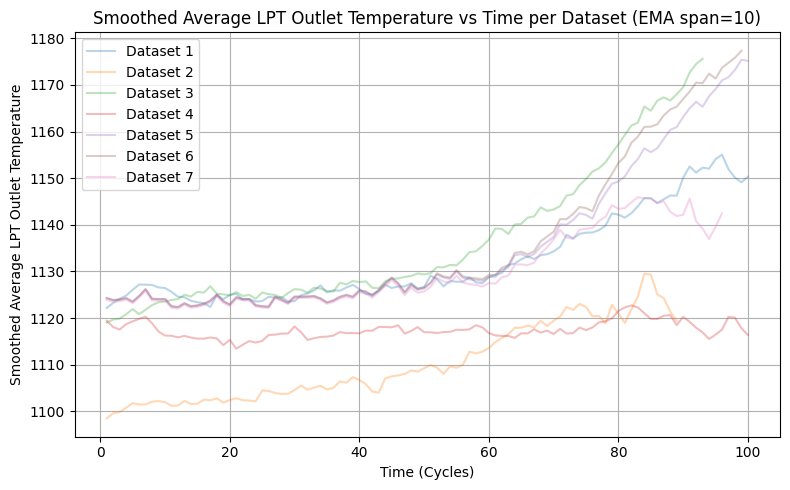

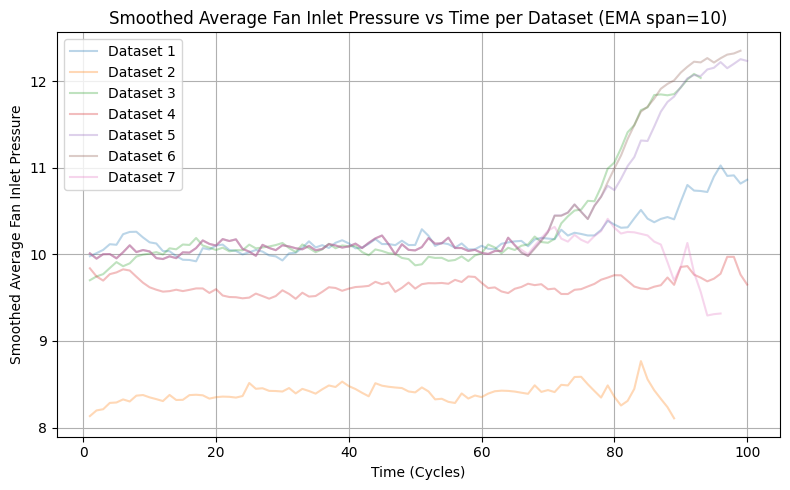

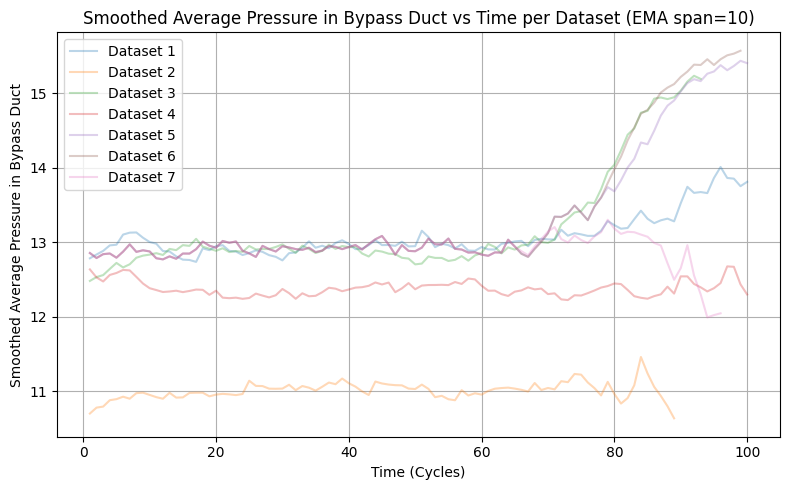

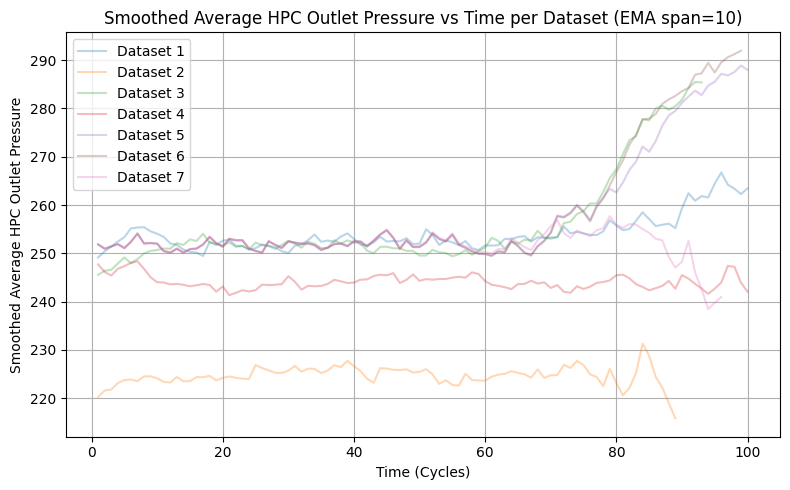

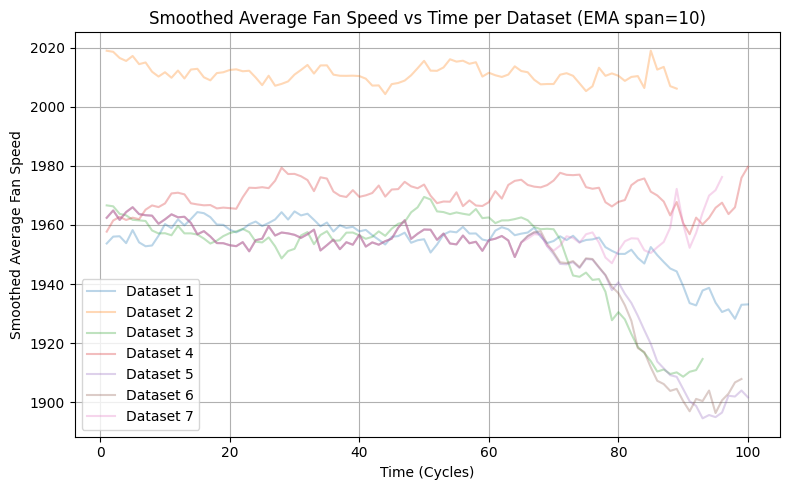

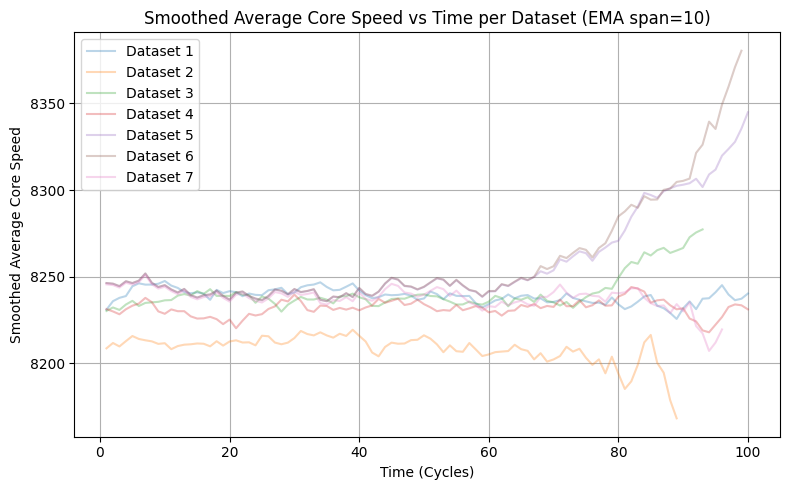

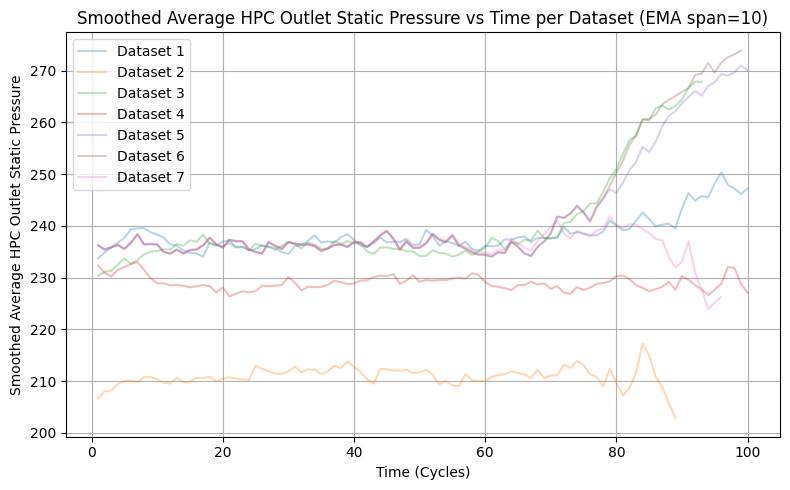

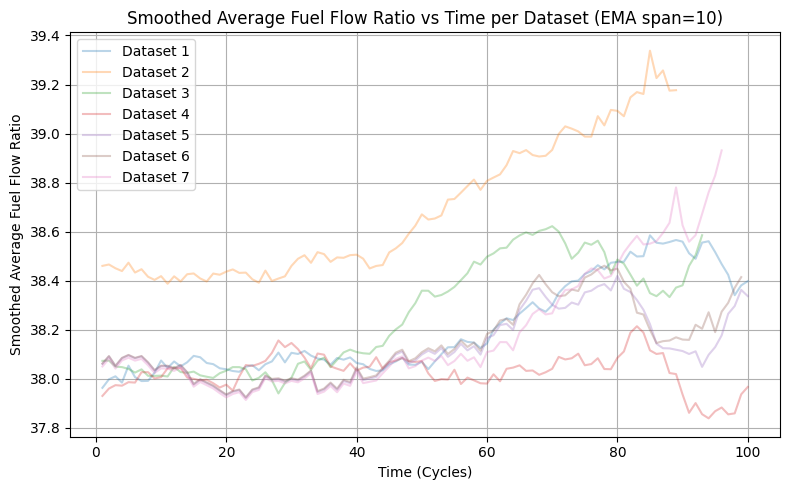

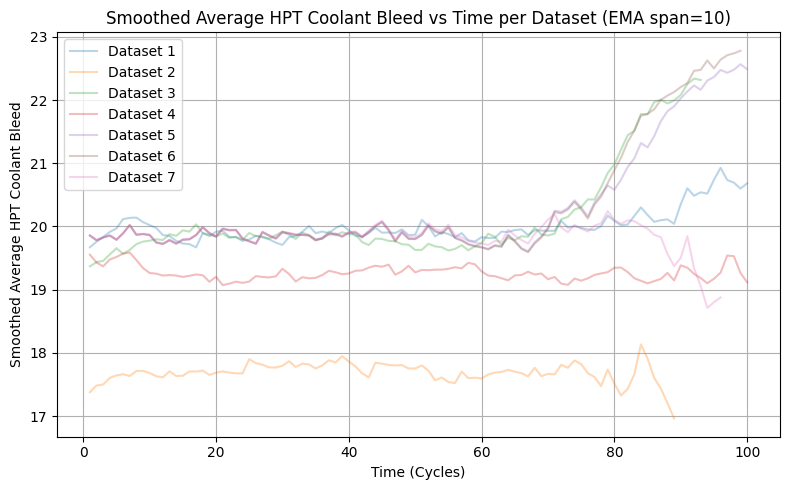

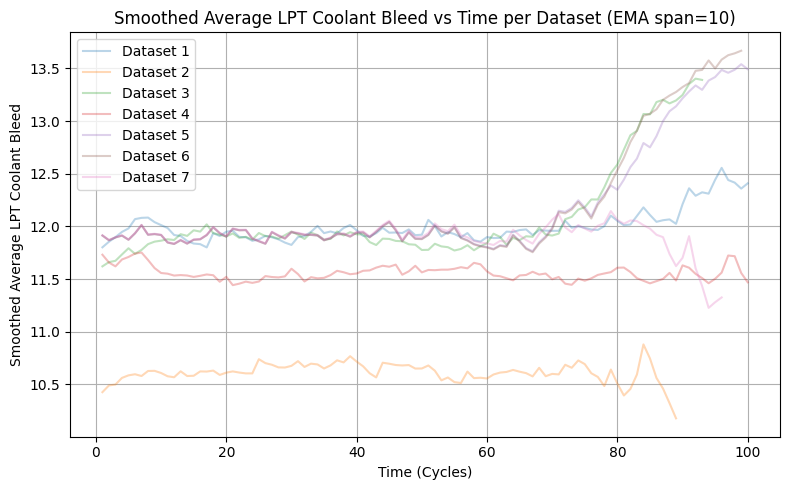


Smoothed sensor DataFrame shape: (100, 91)
Columns: ['Total Temperature at Fan Inlet_DS1', 'Total Temperature at Fan Inlet_DS2', 'Total Temperature at Fan Inlet_DS3', 'Total Temperature at Fan Inlet_DS4', 'Total Temperature at Fan Inlet_DS5', 'Total Temperature at Fan Inlet_DS6', 'Total Temperature at Fan Inlet_DS7', 'LPC Outlet Temperature_DS1', 'LPC Outlet Temperature_DS2', 'LPC Outlet Temperature_DS3', 'LPC Outlet Temperature_DS4', 'LPC Outlet Temperature_DS5', 'LPC Outlet Temperature_DS6', 'LPC Outlet Temperature_DS7', 'HPC Inlet Temperature_DS1', 'HPC Inlet Temperature_DS2', 'HPC Inlet Temperature_DS3', 'HPC Inlet Temperature_DS4', 'HPC Inlet Temperature_DS5', 'HPC Inlet Temperature_DS6', 'HPC Inlet Temperature_DS7', 'LPT Outlet Temperature_DS1', 'LPT Outlet Temperature_DS2', 'LPT Outlet Temperature_DS3', 'LPT Outlet Temperature_DS4', 'LPT Outlet Temperature_DS5', 'LPT Outlet Temperature_DS6', 'LPT Outlet Temperature_DS7', 'Fan Inlet Pressure_DS1', 'Fan Inlet Pressure_DS2', 'Fan 

In [8]:
print("\n=== 5. Average Sensor Trends vs Time per Dataset (Smoothed) ===")

intended_cols = [
    'Total Temperature at Fan Inlet',   # T2
    'LPC Outlet Temperature',           # T24
    'HPC Inlet Temperature',            # T30 
    'LPT Outlet Temperature',           # T50 
    'Fan Inlet Pressure',               # P2
    'Pressure in Bypass Duct',          # P15 
    'HPC Outlet Pressure',              # P30
    'Fan Speed',                        # Nf
    'Core Speed',                       # Nc
    'Engine Pressure Ratio',            # epr
    'HPC Outlet Static Pressure',       # Ps30
    'Fuel Flow Ratio',                  # phi
    'Bypass Ratio',                     # BPR
    'Burner Fuel-Air Ratio',            # farB
    'Bleed Enthalpy',                   # htBleed
    'Demanded Fan Speed',               # Nf_dmd
    'Corrected Fan Speed Ratio',        # PCNfR_dmd
    'HPT Coolant Bleed',                # W31
    'LPT Coolant Bleed'                 # W32
]


sensor_cols = [c for c in intended_cols if c in df_combined.columns]

# Collect smoothed series in a dict to avoid DataFrame fragmentation
smoothed_data = {}

# For each sensor, plot smoothed average vs time for each dataset
for sensor in sensor_cols:
    plt.figure(figsize=(8, 5))
    for dataset in df_combined['dataset'].unique():
        dataset_data = df_combined[df_combined['dataset'] == dataset]
        avg_sensor = dataset_data.groupby('time')[sensor].mean()
        # Apply exponential moving average for smoothing
        smoothed_sensor = avg_sensor.ewm(span=10, adjust=False).mean()
        plt.plot(smoothed_sensor.index, smoothed_sensor.values, label=f'Dataset {dataset}', linewidth=1.5, alpha=0.3)
        # Collect in dict (avoid incremental column assignment)
        smoothed_data[f'{sensor}_DS{dataset}'] = smoothed_sensor
    plt.title(f'Smoothed Average {sensor} vs Time per Dataset (EMA span=10)')
    plt.xlabel('Time (Cycles)')
    plt.ylabel(f'Smoothed Average {sensor}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # Save each sensor plot
    safe_sensor_name = sensor.replace('/', '_').replace(' ', '_')
    plt.savefig(f'plots/sensor_trend_{safe_sensor_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create the smoothed DataFrame at once and de-fragment
smoothed_df = pd.DataFrame(smoothed_data)
smoothed_df = smoothed_df.copy()

# Optional: Display the smoothed_df for inspection
print("\nSmoothed sensor DataFrame shape:", smoothed_df.shape)
print("Columns:", list(smoothed_df.columns))
print(smoothed_df.head())


=== 5. Correlation Matrix: Smoothed Sensors vs RUL per Dataset ===


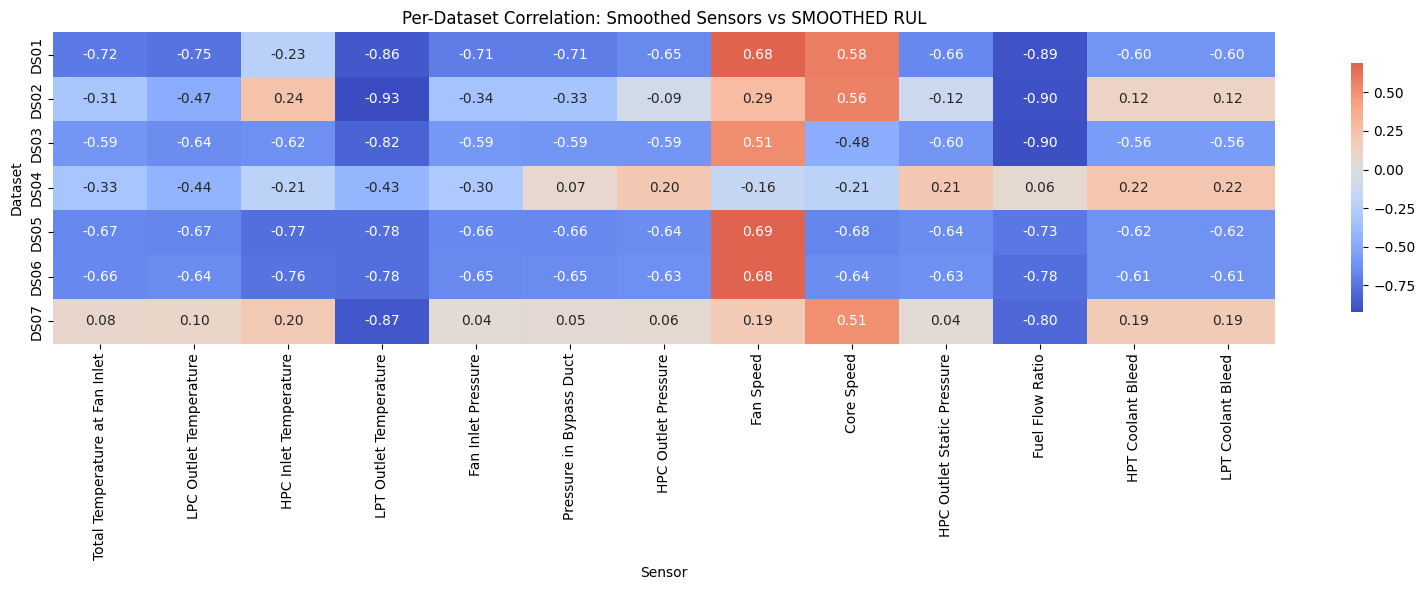


Per-dataset correlations (table):
      Total Temperature at Fan Inlet  LPC Outlet Temperature  \
DS01                          -0.721                  -0.753   
DS02                          -0.305                  -0.471   
DS03                          -0.594                  -0.640   
DS04                          -0.327                  -0.436   
DS05                          -0.666                  -0.670   
DS06                          -0.656                  -0.643   
DS07                           0.081                   0.097   

      HPC Inlet Temperature  LPT Outlet Temperature  Fan Inlet Pressure  \
DS01                 -0.231                  -0.865              -0.707   
DS02                  0.241                  -0.927              -0.336   
DS03                 -0.624                  -0.819              -0.589   
DS04                 -0.207                  -0.426              -0.296   
DS05                 -0.770                  -0.781              -0.660   
DS

In [9]:
# Correlation Matrix: Smoothed Sensors vs RUL per Dataset
print("\n=== 5. Correlation Matrix: Smoothed Sensors vs RUL per Dataset ===")

sensor_bases = [
    'Total Temperature at Fan Inlet',   # T2
    'LPC Outlet Temperature',           # T24
    'HPC Inlet Temperature',            # T30
    'LPT Outlet Temperature',           # T50
    'Fan Inlet Pressure',               # P2
    'Pressure in Bypass Duct',          # P15
    'HPC Outlet Pressure',              # P30
    'Fan Speed',                        # Nf
    'Core Speed',                       # Nc
    'Engine Pressure Ratio',            # epr
    'HPC Outlet Static Pressure',       # Ps30
    'Fuel Flow Ratio',                  # phi
    'Bypass Ratio',                     # BPR
    'Burner Fuel-Air Ratio',            # farB
    'Bleed Enthalpy',                   # htBleed
    'Demanded Fan Speed',               # Nf_dmd
    'Corrected Fan Speed Ratio',        # PCNfR_dmd
    'HPT Coolant Bleed',                # W31
    'LPT Coolant Bleed'                 # W32
]

sensors_present = [s for s in sensor_bases if s in df_combined.columns]
datasets = sorted(df_combined['dataset'].unique())
ds_labels = [f'DS{int(d):02d}' for d in datasets]
corr_by_dataset = pd.DataFrame(index=ds_labels, columns=sensors_present, dtype=float)

for d, ds_label in zip(datasets, ds_labels):
    df_d = df_combined[df_combined['dataset'] == d].sort_values('time')
    
    # 1. Calculate Average RUL (fleet average at time t)
    avg_rul = df_d.groupby('time')['Remaining Useful Life'].mean()  
    
    # 2. Smooth the Average RUL for correlation consistency
    rul_sm = avg_rul.ewm(span=10, adjust=False).mean()

    for sensor in sensors_present:
        col_name = f'{sensor}_DS{int(d)}'
        if col_name in smoothed_df.columns:
            s_sm = smoothed_df[col_name]
        else:
            # Fallback: compute if missing
            s_sm = df_d.groupby('time')[sensor].mean().ewm(span=10, adjust=False).mean()
            
        # Correlate smoothed sensor against smoothed RUL
        valid = pd.concat([s_sm, rul_sm], axis=1, join='inner').dropna()
        corr_by_dataset.loc[ds_label, sensor] = valid.iloc[:, 0].corr(valid.iloc[:, 1]) if len(valid) > 5 else np.nan

# Plot heatmap (datasets x sensors)
plt.figure(figsize=(16, max(6, len(ds_labels) * 0.6)))
sns.heatmap(corr_by_dataset, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'shrink': 0.8})
plt.title('Per-Dataset Correlation: Smoothed Sensors vs SMOOTHED RUL')
plt.xlabel('Sensor')
plt.ylabel('Dataset')
plt.tight_layout()
plt.show()

print("\nPer-dataset correlations (table):")
print(corr_by_dataset.round(3))


=== 6. Lagged Correlation Matrix: Smoothed Sensors vs RUL per Dataset ===


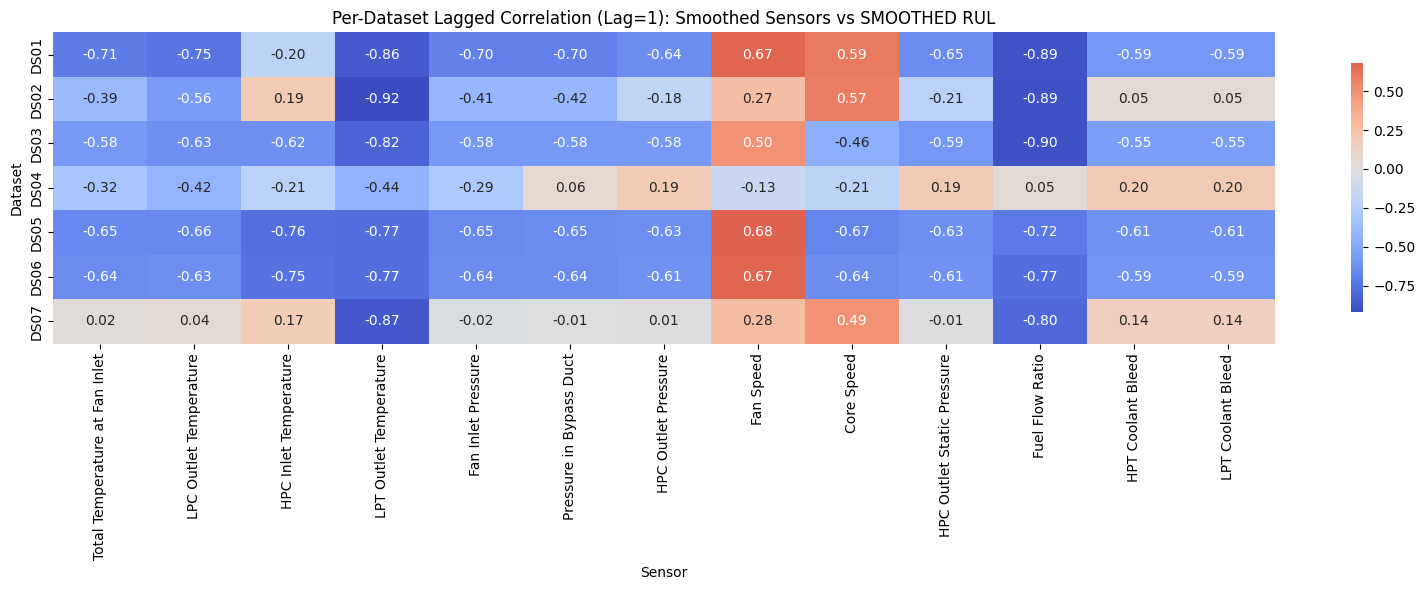

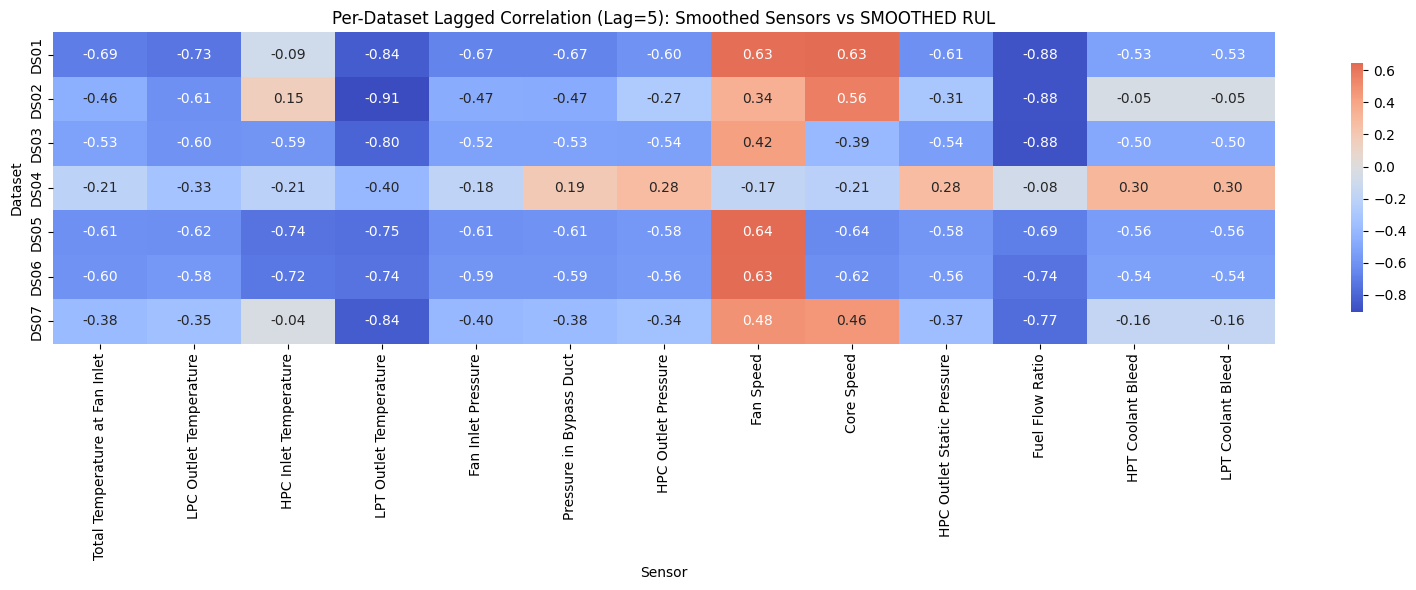

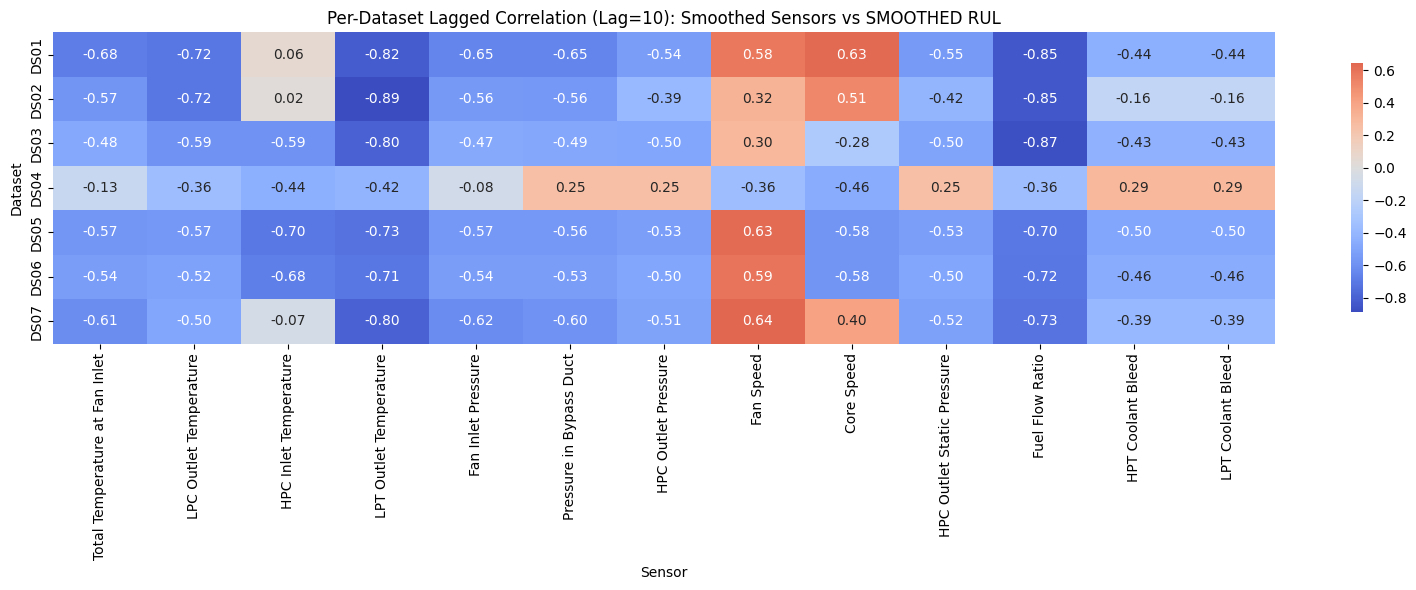

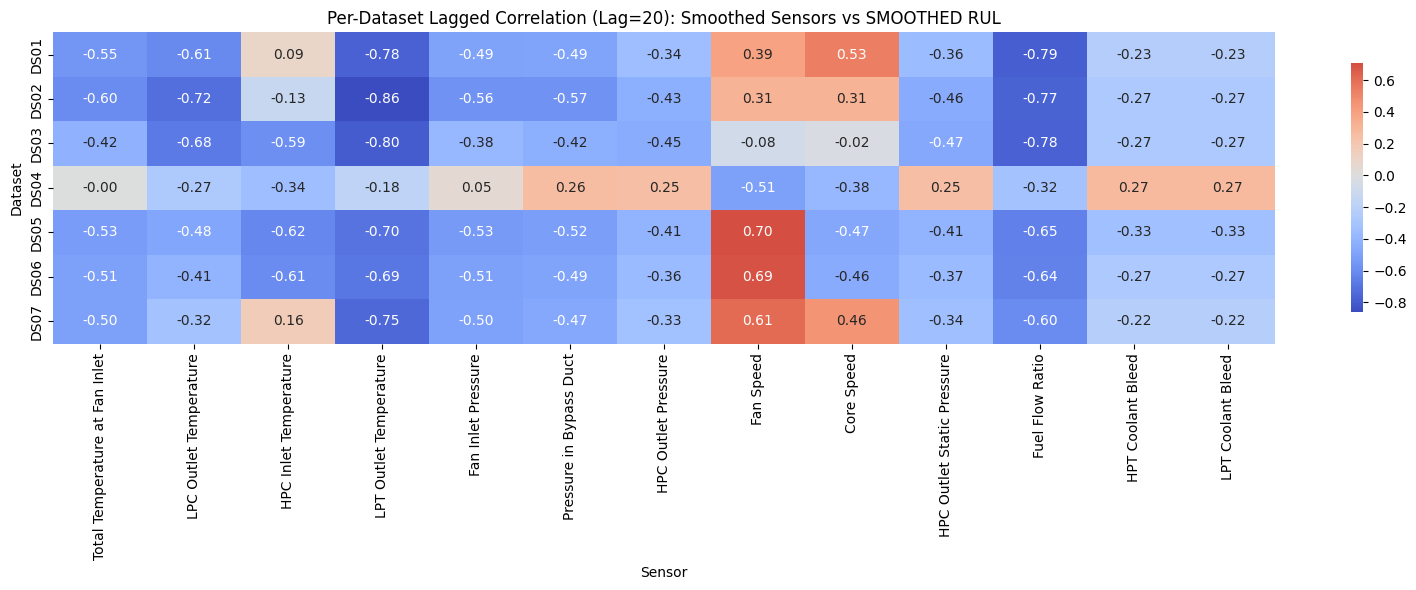


Lagged correlations (example Lag=10):
      Total Temperature at Fan Inlet  LPC Outlet Temperature  \
DS01                          -0.683                  -0.717   
DS02                          -0.575                  -0.716   
DS03                          -0.484                  -0.587   
DS04                          -0.131                  -0.358   
DS05                          -0.570                  -0.568   
DS06                          -0.539                  -0.518   
DS07                          -0.615                  -0.500   

      HPC Inlet Temperature  LPT Outlet Temperature  Fan Inlet Pressure  \
DS01                  0.056                  -0.823              -0.648   
DS02                  0.022                  -0.892              -0.561   
DS03                 -0.587                  -0.796              -0.475   
DS04                 -0.439                  -0.421              -0.079   
DS05                 -0.700                  -0.732              -0.567  

In [10]:
print("\n=== 6. Lagged Correlation Matrix: Smoothed Sensors vs RUL per Dataset ===")

sensor_bases_lagged = [
    'Total Temperature at Fan Inlet',   # T2
    'LPC Outlet Temperature',           # T24
    'HPC Inlet Temperature',            # T30
    'LPT Outlet Temperature',           # T50
    'Fan Inlet Pressure',               # P2
    'Pressure in Bypass Duct',          # P15
    'HPC Outlet Pressure',              # P30
    'Fan Speed',                        # Nf
    'Core Speed',                       # Nc
    'Engine Pressure Ratio',            # epr
    'HPC Outlet Static Pressure',       # Ps30
    'Fuel Flow Ratio',                  # phi
    'Bypass Ratio',                     # BPR
    'Burner Fuel-Air Ratio',            # farB
    'Bleed Enthalpy',                   # htBleed
    'Demanded Fan Speed',               # Nf_dmd
    'Corrected Fan Speed Ratio',        # PCNfR_dmd
    'HPT Coolant Bleed',                # W31
    'LPT Coolant Bleed'                 # W32
]

sensors_present = [s for s in sensor_bases_lagged if s in df_combined.columns]
datasets = sorted(df_combined['dataset'].unique())
ds_labels = [f'DS{int(d):02d}' for d in datasets]
lags = [1, 5, 10, 20]

# Build a result DataFrame per lag: (datasets x sensors)
lagged_results = {lag: pd.DataFrame(index=ds_labels, columns=sensors_present, dtype=float) for lag in lags}

for d, ds_label in zip(datasets, ds_labels):
    df_d = df_combined[df_combined['dataset'] == d].sort_values('time')
    
    # 1. Calculate Average RUL (fleet average at time t)
    avg_rul = df_d.groupby('time')['Remaining Useful Life'].mean()  
    
    # 2. Smooth the Average RUL for correlation consistency
    rul_sm = avg_rul.ewm(span=10, adjust=False).mean()

    for sensor in sensors_present:
        col_name = f'{sensor}_DS{int(d)}'
        if col_name in smoothed_df.columns:
            s_sm = smoothed_df[col_name]
        else:
            # Fallback: compute if missing
            s_sm = df_d.groupby('time')[sensor].mean().ewm(span=10, adjust=False).mean()
            
        for lag in lags:
            # Shift the SMOOTHED SENSOR data
            shifted = s_sm.shift(lag)
            
            # Correlate shifted sensor (at t-lag) against SMOOTHED RUL (at t)
            valid = pd.concat([shifted, rul_sm], axis=1, join='inner').dropna()
            
            lagged_results[lag].loc[ds_label, sensor] = valid.iloc[:, 0].corr(valid.iloc[:, 1]) if len(valid) > 5 else np.nan

# Plot one heatmap per lag
for lag in lags:
    plt.figure(figsize=(16, max(6, len(ds_labels) * 0.6)))
    sns.heatmap(lagged_results[lag], annot=True, fmt='.2f', cmap='coolwarm', center=0,
                cbar_kws={'shrink': 0.8})
    plt.title(f'Per-Dataset Lagged Correlation (Lag={lag}): Smoothed Sensors vs SMOOTHED RUL')
    plt.xlabel('Sensor')
    plt.ylabel('Dataset')
    plt.tight_layout()
    plt.show()

print("\nLagged correlations (example Lag=10):")
print(lagged_results[10].round(3))

### Feature Selection

In [ ]:
print("\n=== 7. Preparing Feature Dataset ===")

selected_features = [
    'HPC Outlet Pressure', 
    'LPT Coolant Bleed', 
    'Burner Fuel-Air Ratio',
    'Demanded Fan Speed', 
    'Fan Speed',
    'Core Speed', 
    'Pressure in Bypass Duct', 
    'Fuel Flow Ratio', 
    'LPT Outlet Temperature',
    'Altitude', 
    'Mach Number', 
    'Throttle Resolver Angle' 
]
# The final features to use, ensuring only valid columns are selected
final_features = [f for f in selected_features if f in df_combined.columns]

# --- 1. Create the base gold DataFrame (filtered features only) ---
required_aux_cols = ['unit', 'time', 'Remaining Useful Life', 'dataset']
gold_df = df_combined[required_aux_cols + final_features].copy() 

EMA_SPAN = 10
sensor_cols_for_ema = [f for f in final_features if f not in ['Altitude', 'Mach Number', 'Throttle Resolver Angle']]

for sensor in sensor_cols_for_ema:
    # Apply EMA per individual engine unit
    gold_df[f'{sensor}_EMA'] = gold_df.groupby('unit')[sensor].transform(
        lambda x: x.ewm(span=EMA_SPAN, adjust=False).mean()
    )


print(f"Feature engineering complete. Final DataFrame shape: {gold_df.shape}")
print(f"Smoothed features added: {gold_df.filter(like='_EMA').columns.tolist()}")

# Display the first few rows to show the new columns
print("\nExample of Smoothed Features:")
print(gold_df[['unit', 'time', 'LPT Outlet Temperature', 'LPT Outlet Temperature_EMA']].head(50).to_markdown(index=False, floatfmt='.4f'))


=== 7. Preparing Feature Dataset ===
Feature engineering complete. Final DataFrame shape: (54874178, 20)
Smoothed features added: ['HPC Outlet Pressure_EMA', 'LPT Coolant Bleed_EMA', 'Fan Speed_EMA', 'Core Speed_EMA', 'Pressure in Bypass Duct_EMA', 'Fuel Flow Ratio_EMA', 'LPT Outlet Temperature_EMA']

Example of Smoothed Features:
| unit     |   time |   LPT Outlet Temperature |   LPT Outlet Temperature_EMA |
|:---------|-------:|-------------------------:|-----------------------------:|
| DS01_001 |      1 |                1269.2756 |                    1269.2756 |
| DS01_001 |      1 |                1269.1772 |                    1269.2577 |
| DS01_001 |      1 |                1269.1674 |                    1269.2413 |
| DS01_001 |      1 |                1269.5187 |                    1269.2917 |
| DS01_001 |      1 |                1269.2540 |                    1269.2848 |
| DS01_001 |      1 |                1269.1872 |                    1269.2671 |
| DS01_001 |      1 |     

### Train Test Split

In [16]:
def split_data_by_unit(df, train_sets, oot_sets):
    """
    Splits data into TRAIN, VAL, TEST, and OOT based on dataset IDs.
    
    OOT: Datasets specified in oot_sets (e.g., DS02, DS07).
    TRAIN/VAL/TEST: Split randomly by unit on datasets in train_sets.
    """
    
    # 1. Separate OOT set (Datasets 2 and 7)
    df_oot = df[df['dataset'].isin(oot_sets)].copy()
    
    # 2. Get the remaining data for training/internal testing
    df_internal = df[df['dataset'].isin(train_sets)].copy()
    
    # 3. Split Internal data into Train and Test (by unit)
    internal_units = df_internal['unit'].unique()
    
    # Use sklearn to split units for internal test (15% of units)
    train_val_units, test_units = train_test_split(
        internal_units, test_size=0.15, random_state=42
    )
    
    df_test = df_internal[df_internal['unit'].isin(test_units)].copy()
    df_train_val = df_internal[df_internal['unit'].isin(train_val_units)].copy()
    
    # 4. Split Train/Validation (by unit)
    train_val_units_shuffled = df_train_val['unit'].unique()
    
    # Use sklearn to split units for validation (15% of remaining units)
    train_units, val_units = train_test_split(
        train_val_units_shuffled, test_size=0.15, random_state=42
    )
    
    df_val = df_train_val[df_train_val['unit'].isin(val_units)].copy()
    df_train = df_train_val[df_train_val['unit'].isin(train_units)].copy()

    # Resetting index is crucial for sequential data preparation later
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    df_oot = df_oot.reset_index(drop=True)
    
    return df_train, df_val, df_test, df_oot

print("\n=== 8. Train/Validation/Test/OOT Split ===")

df_train, df_val, df_test, df_oot = split_data_by_unit(gold_df, TRAIN_SETS, OOT_SETS)

# Check counts
print(f"Total rows: {len(gold_df):,}")
print(f"Training rows (Internal Train Units): {len(df_train):,}")
print(f"Validation rows (Internal Validation Units): {len(df_val):,}")
print(f"Test rows (Internal Test Units): {len(df_test):,}")
print(f"OOT rows (Datasets {OOT_SETS}): {len(df_oot):,}")
# Check unit assignment
print(f"\nTraining units (example): {df_train['unit'].unique()[:3]}")
print(f"Validation units (example): {df_val['unit'].unique()[:3]}")
print(f"Test units (example): {df_test['unit'].unique()[:3]}")


=== 8. Train/Validation/Test/OOT Split ===
Total rows: 54,874,178
Training rows (Internal Train Units): 26,898,226
Validation rows (Internal Validation Units): 6,905,795
Test rows (Internal Test Units): 7,333,005
OOT rows (Datasets [2, 7]): 13,737,152

Training units (example): ['DS01_001' 'DS01_002' 'DS01_003']
Validation units (example): ['DS01_005' 'DS04_005' 'DS04_006']
Test units (example): ['DS01_006' 'DS03_004' 'DS03_010']


### Normalise Data

In [17]:
def normalize_and_clip_rul(df_train, df_val, df_test, df_oot, sensor_cols_ema, healthy_window):
    """
    Normalizes features based ONLY on training data statistics and applies RUL clipping.
    
    Returns: Scaler object (fitted on train) and scaled DataFrames.
    """
    
    # 1. IDENTIFY NORMALIZATION PARAMETERS (from TRAIN data only)
    
    # a. Determine the feature columns to be scaled (the EMA columns)
    scale_cols = [f'{s}_EMA' for s in sensor_cols_ema]
    
    # b. Calculate Healthy Baseline Mean (S_i,min) for each feature/unit in TRAIN
    # We use the mean of the healthy window across ALL training units as the global baseline (S_i,min)
    train_healthy = df_train[df_train['time'] <= healthy_window]
    healthy_baseline_mean = train_healthy[scale_cols].mean().to_dict()
    
    # c. Calculate Global Maximum (S_i,max) for each feature in TRAIN
    # This defines the top of our scale.
    global_max = df_train[scale_cols].max().to_dict()
    
    # Store parameters in a dictionary keyed by original sensor name
    norm_params = {}
    for sensor in sensor_cols_ema:
        ema_col = f'{sensor}_EMA'
        norm_params[sensor] = {
            'min': healthy_baseline_mean[ema_col],
            'max': global_max[ema_col]
        }
    
    # 2. APPLY NORMALIZATION TO ALL SETS
    
    def apply_normalization(df_set):
        df_norm = df_set.copy()
        
        for sensor in sensor_cols_ema:
            ema_col = f'{sensor}_EMA'
            norm_col = f'{sensor}_NORM'
            
            min_val = norm_params[sensor]['min']
            max_val = norm_params[sensor]['max']
            
            # Normalization: (Actual EMA - Healthy Baseline) / (Max Deviation)
            deviation_range = max_val - min_val
            
            # Apply scaling. Use .clip(lower=0) to ensure health indicators are non-negative.
            df_norm[norm_col] = (df_norm[ema_col] - min_val) / deviation_range
            df_norm[norm_col] = df_norm[norm_col].clip(lower=0).copy()
            
            # Clip the final normalized value to 1.0, though MinMax usually ensures this.
            df_norm[norm_col] = df_norm[norm_col].clip(upper=1.0).copy()
            
        return df_norm

    df_train_norm = apply_normalization(df_train)
    df_val_norm = apply_normalization(df_val)
    df_test_norm = apply_normalization(df_test)
    df_oot_norm = apply_normalization(df_oot)
    
    # 3. APPLY RUL CLIPPING (Common prognostic technique to cap the target variable)
    RUL_CLIP_MAX = 125 # Cap RUL at 125 cycles to focus model learning on the critical phase
    
    df_train_norm['RUL_Clipped'] = df_train_norm['Remaining Useful Life'].clip(upper=RUL_CLIP_MAX)
    df_val_norm['RUL_Clipped'] = df_val_norm['Remaining Useful Life'].clip(upper=RUL_CLIP_MAX)
    df_test_norm['RUL_Clipped'] = df_test_norm['Remaining Useful Life'].clip(upper=RUL_CLIP_MAX)
    df_oot_norm['RUL_Clipped'] = df_oot_norm['Remaining Useful Life'].clip(upper=RUL_CLIP_MAX)
    
    return df_train_norm, df_val_norm, df_test_norm, df_oot_norm, norm_params

In [18]:
print("\n=== 9. Normalization (Per-Engine Baseline) & RUL Clipping ===")

df_train_norm, df_val_norm, df_test_norm, df_oot_norm, norm_params = normalize_and_clip_rul(
    df_train, df_val, df_test, df_oot, sensor_cols_for_ema, HEALTHY_WINDOW
)

print(f"Normalization complete. Train RUL clipped max: {df_train_norm['RUL_Clipped'].max()}")
print(f"Number of Normalized features: {len(df_train_norm.filter(like='_NORM').columns)}")

# Display the normalization parameters learned from TRAIN data
print("\nExample Normalization Parameters (Learned from TRAIN):")
print(pd.DataFrame(norm_params).T[['min', 'max']].head(5).to_markdown(floatfmt='.2f'))

print("\nExample Normalized OOT Data:")
print(df_oot_norm[['unit', 'time', 'LPT Outlet Temperature_NORM', 'RUL_Clipped']].head(5).to_markdown(index=False, floatfmt='.4f'))


=== 9. Normalization (Per-Engine Baseline) & RUL Clipping ===
Normalization complete. Train RUL clipped max: 99
Number of Normalized features: 7

Example Normalization Parameters (Learned from TRAIN):
|                         |     min |     max |
|:------------------------|--------:|--------:|
| HPC Outlet Pressure     |  253.13 |  477.04 |
| LPT Coolant Bleed       |   11.98 |   20.70 |
| Fan Speed               | 1955.30 | 2290.51 |
| Core Speed              | 8241.76 | 8916.41 |
| Pressure in Bypass Duct |   12.98 |   20.40 |

Example Normalized OOT Data:
| unit     |   time |   LPT Outlet Temperature_NORM |   RUL_Clipped |
|:---------|-------:|------------------------------:|--------------:|
| DS02_002 |      1 |                        0.4510 |            74 |
| DS02_002 |      1 |                        0.4508 |            74 |
| DS02_002 |      1 |                        0.4519 |            74 |
| DS02_002 |      1 |                        0.4520 |            74 |
| DS02_002 |

### Data Sequencing for LSTM

In [22]:
# PyTorch Custom Dataset Class
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        # Convert NumPy arrays to PyTorch tensors (Float32 is standard)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # RUL is single output
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def create_sequences(df, sequence_length, features):
    """Converts the dataframe into sequences (samples, timesteps, features) for LSTM."""
    X, y = [], []
    
    for unit in df['unit'].unique():
        unit_df = df[df['unit'] == unit].copy()
        
        # Use the NORM features as inputs (X)
        feature_data = unit_df[features].values
        
        # Use RUL_Clipped as the target (y)
        target_data = unit_df['RUL_Clipped'].values.reshape(-1, 1)

        for i in range(len(unit_df) - sequence_length + 1):
            # Create a sequence of input features
            X.append(feature_data[i:i + sequence_length])
            # The target RUL is the value at the END of the sequence
            y.append(target_data[i + sequence_length - 1])
            
    return np.array(X), np.array(y).flatten()


class RulLSTM(nn.Module):
    """Defines the PyTorch LSTM model architecture for RUL regression."""
    def __init__(self, input_size, hidden_size=100, num_layers=2, dropout=0.2):
        super(RulLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM Layer 1 (return_sequences=True equivalent)
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        
        # LSTM Layer 2 (return_sequences=False equivalent)
        # We need to manually stack the second LSTM if we want different hidden sizes 
        # but here we'll use a single layer and then a dense layer to match the complexity.
        # Simple stacked LSTM with different hidden size for illustration
        self.lstm2 = nn.LSTM(hidden_size, 50, batch_first=True) 
        self.dropout2 = nn.Dropout(dropout)
        
        # Output layer for regression (RUL is a single continuous value)
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        
        # LSTM 1
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        
        # LSTM 2 (Take the output from the last timestep: out[:, -1, :])
        # We need to process the whole sequence again, but simpler is to use the last output from LSTM 2
        # Since lstm1 returns sequences, we can feed that entire sequence to lstm2
        out, (hn, cn) = self.lstm2(out)
        
        # Take the hidden state of the LAST time step from the last layer (hn[num_layers-1])
        # Since lstm2 has 1 layer (hidden_size=50), we use the hidden state 'hn'
        # hn shape: (num_layers, batch_size, hidden_size)
        
        # PyTorch LSTM: hidden state `hn` of shape (num_layers, batch_size, hidden_size)
        # We use the final hidden state of the sequence from the last layer (hn[-1, :, :])
        out = hn[-1, :, :] 
        out = self.dropout2(out)
        
        # Fully Connected Layer
        out = self.fc(out)
        return out


def train_pytorch_model(model, train_loader, val_loader, optimizer, loss_fn, epochs, device):
    """Custom PyTorch training loop."""
    
    # Setup for early stopping
    patience = 5
    min_val_loss = float('inf')
    epochs_no_improve = 0
    
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            
            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)

        # Validation phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = loss_fn(outputs, targets)
                val_loss += loss.item() * inputs.size(0)

        # Calculate average losses
        train_loss = np.sqrt(train_loss / len(train_loader.dataset))
        val_loss = np.sqrt(val_loss / len(val_loader.dataset))

        print(f'Epoch {epoch+1}/{epochs}, Train RMSE: {train_loss:.4f}, Val RMSE: {val_loss:.4f}')

        # Early Stopping check
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            epochs_no_improve = 0
            # Optional: Save the best model state here
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f"Early stopping triggered after {patience} epochs with no improvement.")
                break


def evaluate_pytorch_model(model, data_loader, device):
    """Custom PyTorch evaluation function."""
    model.eval()
    total_loss = 0
    
    # Mean Squared Error Loss (for consistency with RMSE calculation)
    mse_loss = nn.MSELoss(reduction='sum') 
    
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = mse_loss(outputs, targets)
            total_loss += loss.item()
            
    # Calculate RMSE
    rmse = np.sqrt(total_loss / len(data_loader.dataset))
    
    # Calculate MAE (manual calculation for simplicity)
    all_targets = []
    all_predictions = []
    with torch.no_grad(): # Ensure we are in a no_grad context for the detach() call
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            
            # FIX: Detach the tensor before calling .cpu().numpy()
            all_targets.append(targets.detach().cpu().numpy())
            all_predictions.append(outputs.detach().cpu().numpy())

    all_targets = np.concatenate(all_targets).flatten()
    all_predictions = np.concatenate(all_predictions).flatten()
    mae = np.mean(np.abs(all_targets - all_predictions))
    
    return rmse, mae

### LSTM Model Training

In [20]:
print("\n=== 10. Sequence Preparation and PyTorch LSTM Model Training ===")

# Define input parameters for the LSTM
NORM_FEATURES = df_train_norm.filter(like='_NORM').columns.tolist()

# 1. Create sequences (NumPy arrays)
X_train, y_train = create_sequences(df_train_norm, SEQUENCE_LENGTH, NORM_FEATURES)
X_val, y_val = create_sequences(df_val_norm, SEQUENCE_LENGTH, NORM_FEATURES)

print(f"Sequence Preparation Complete.")
print(f"X_train shape: {X_train.shape} (Samples, Timesteps, Features)")
print(f"y_train shape: {y_train.shape}")

# 2. Create PyTorch Datasets and DataLoaders
train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. Build Model, Loss, and Optimizer
input_size = X_train.shape[2]
lstm_model = RulLSTM(input_size=input_size).to(DEVICE)

# Note: We use MSE Loss since RMSE loss function in PyTorch is usually calculated 
# AFTER the loss accumulation, not during the backward pass.
loss_fn = nn.MSELoss() 
optimizer = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

# Print model structure
print("\nPyTorch Model Summary:")
print(lstm_model)

# 4. Train Model
train_pytorch_model(lstm_model, train_loader, val_loader, optimizer, loss_fn, EPOCHS, DEVICE)

print("\n--- Model Training Complete ---")


=== 10. Sequence Preparation and PyTorch LSTM Model Training ===
Sequence Preparation Complete.
X_train shape: (26897095, 30, 7) (Samples, Timesteps, Features)
y_train shape: (26897095,)

PyTorch Model Summary:
RulLSTM(
  (lstm1): LSTM(7, 100, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(100, 50, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)
Epoch 1/50, Train RMSE: 18.5898, Val RMSE: 19.0327
Epoch 2/50, Train RMSE: 16.9151, Val RMSE: 18.6083
Epoch 3/50, Train RMSE: 16.6145, Val RMSE: 18.7381
Epoch 4/50, Train RMSE: 16.4352, Val RMSE: 18.2293
Epoch 5/50, Train RMSE: 16.3184, Val RMSE: 18.5843
Epoch 6/50, Train RMSE: 16.2172, Val RMSE: 18.6031
Epoch 7/50, Train RMSE: 16.1681, Val RMSE: 18.6656
Epoch 8/50, Train RMSE: 16.1226, Val RMSE: 18.4944
Epoch 9/50, Train RMSE: 16.0683, Val RMSE: 18.6724
Early stopping triggered after 5 epochs with no improvement.

--- Model Training Comple

### Model Eval

In [28]:
print("\n=== 11. Model Evaluation (Test & OOT Sets) ===")

# Prepare test and OOT data sequences and loaders
X_test, y_test = create_sequences(df_test_norm, SEQUENCE_LENGTH, NORM_FEATURES)
X_oot, y_oot = create_sequences(df_oot_norm, SEQUENCE_LENGTH, NORM_FEATURES)

test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)
oot_loader = DataLoader(TimeSeriesDataset(X_oot, y_oot), batch_size=BATCH_SIZE, shuffle=False)

# --- Internal Test Set Evaluation ---
rmse_test, mae_test = evaluate_pytorch_model(lstm_model, test_loader, DEVICE)

# --- OOT Test Set Evaluation (The ultimate generalization test) ---
rmse_oot, mae_oot = evaluate_pytorch_model(lstm_model, oot_loader, DEVICE)


print(f"\nEvaluation on Test Set (Internal Units):")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")

print(f"\nEvaluation on OOT Set (Datasets {OOT_SETS} - Generalization Test):")
print(f"Root Mean Squared Error (RMSE): {rmse_oot:.4f}")
print(f"Mean Absolute Error (MAE): {mae_oot:.4f}")


torch.save(lstm_model.state_dict(), MODEL_SAVE_PATH)
print(f"\nModel saved successfully to {MODEL_SAVE_PATH}")


=== 11. Model Evaluation (Test & OOT Sets) ===

Evaluation on Test Set (Internal Units):
Root Mean Squared Error (RMSE): 18.0645
Mean Absolute Error (MAE): 13.5596

Evaluation on OOT Set (Datasets [2, 7] - Generalization Test):
Root Mean Squared Error (RMSE): 15.6932
Mean Absolute Error (MAE): 11.6439

Model saved successfully to rul_lstm_model.pt


### Model Explainability with LIME


=== 12. Model Explainability using LIME ===
Explaining prediction for a randomly selected OOT sample (last timestep features)...

LIME Explanation Plot (Local Feature Importance):


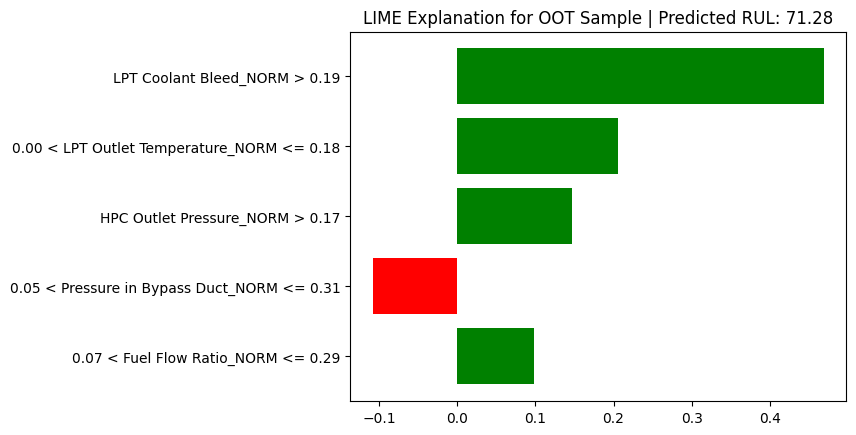


Model interpretability step using LIME complete.


In [37]:
print("\n=== 12. Model Explainability using LIME ===")

# 1. Prepare Data for LIME
# LIME requires the background data (X_train) and feature names.
X_train_np = train_loader.dataset.X.cpu().numpy()
X_oot_np = oot_loader.dataset.X.cpu().numpy()

# LIME operates on 2D data for explanation, so we flatten the sequence dimension (axis=1)
# We will focus on the features at the last timestep of the sequence: X[:, -1, :]
training_data_for_lime = X_train_np[:, -1, :]

# Select a single critical instance from the OOT set (e.g., the last sequence of the first engine)
# The LIME explainer expects a 1D feature vector for the instance.
explain_instance_sequence = X_oot_np[np.random.choice(len(X_oot_np))] # Random critical sample
explain_instance_2d = explain_instance_sequence[-1, :] # The features at the last timestep (L-1)

# 2. Define the LIME Prediction Function
def lime_predictor(data_2d_np):
    """
    Wraps the PyTorch model for LIME.
    Input: 2D NumPy array (N_samples, N_features)
    Output: 2D NumPy array (N_samples, 1) of RUL predictions.
    """
    # 1. Prepare the 3D tensor: stack history (L-1 timesteps) with the perturbed last timestep
    N_samples = data_2d_np.shape[0]
    
    # Create the 3D input tensor
    X_3d_perturbed = np.zeros((N_samples, SEQUENCE_LENGTH, len(NORM_FEATURES)))
    
    # Extract the common history (t=0 to t=L-2) from the original sequence
    history_part = explain_instance_sequence[:-1, :]
    
    for i in range(N_samples):
        # Stack the fixed history with the LIME-perturbed last timestep (data_2d_np[i, :])
        X_3d_perturbed[i, :-1, :] = history_part
        X_3d_perturbed[i, -1, :] = data_2d_np[i, :]

    # 2. Convert to PyTorch Tensor and run model
    X_tensor = torch.tensor(X_3d_perturbed, dtype=torch.float32).to(DEVICE)
    
    # Run in evaluation mode
    lstm_model.eval()
    with torch.no_grad():
        outputs = lstm_model(X_tensor)
        
    # Outputs is [N_samples, 1]. Return as NumPy array
    return outputs.cpu().numpy()


# 3. Initialize LIME Explainer
explainer = LimeTabularExplainer(
    training_data=training_data_for_lime,
    feature_names=NORM_FEATURES,
    class_names=['RUL'], # Regression target name
    mode='regression',
    verbose=False
)

# 4. Generate Explanation
print(f"Explaining prediction for a randomly selected OOT sample (last timestep features)...")

# The prediction LIME is trying to explain (just the last timestep's features)
explanation = explainer.explain_instance(
    data_row=explain_instance_2d,
    predict_fn=lime_predictor,
    num_features=5, # Show top 5 features
    num_samples=1000 # Number of perturbations LIME will perform
)

# 5. Visualize Results
predicted_rul = lime_predictor(explain_instance_2d.reshape(1, -1))[0][0]
true_rul = explain_instance_sequence[-1, :] # The features at the last timestep (L-1)


print("\nLIME Explanation Plot (Local Feature Importance):")
fig = explanation.as_pyplot_figure()
plt.title(f"LIME Explanation for OOT Sample | Predicted RUL: {predicted_rul:.2f}")
plt.savefig('plots/lime_explanation_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nModel interpretability step using LIME complete.")
